In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

In [2]:
image = cv2.imread('img_task2.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

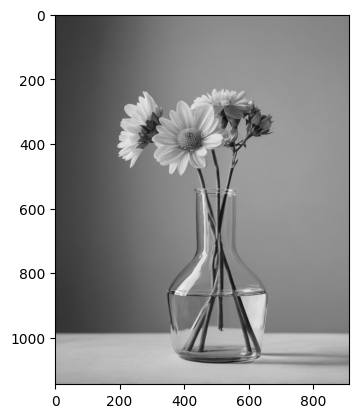

In [3]:
plt.imshow(image_gray, cmap="gray")

# Зашумить изображение при помощи шума гаусса, постоянного шума.

In [4]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ...,   0, 187,   0],
       [111, 139,   0, ...,   0,   0,  92],
       [ 76,   0,  40, ...,   0, 126,  17],
       ...,
       [  0,  51,   0, ...,   0,  86,   0],
       [ 14, 160,   6, ...,  54,   0, 212],
       [115,  40,  94, ...,  63,   0,   0]],
      shape=(1144, 912), dtype=uint8)

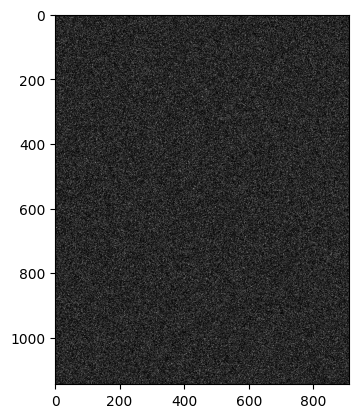

In [5]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [7]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [8]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

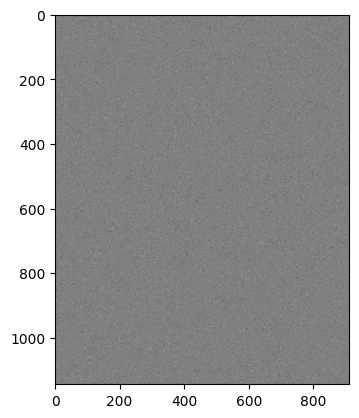

In [9]:
plt.imshow(bg_image, cmap="gray")

In [10]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

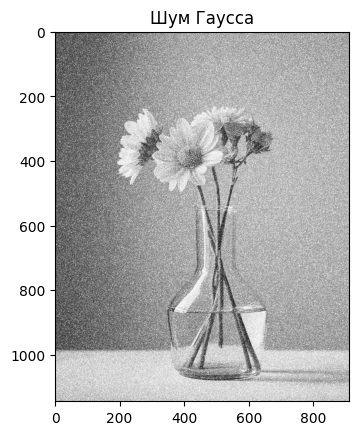

In [27]:
plt.title('Шум Гаусса')
plt.imshow(image_noise_gauss, cmap="gray")

In [12]:
import copy

image_noise_sp = copy.deepcopy(image_gray)

image_noise_sp[zeros_pixel] = 0
image_noise_sp[ones_pixel] = 255

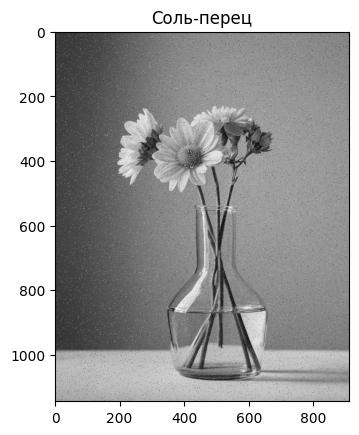

In [26]:
plt.title('Соль-перец')
plt.imshow(image_noise_sp, cmap="gray")

# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [14]:
def mse_ssim(original, processed, index = ''):
    mse = mean_squared_error(original, processed)
    ssim = structural_similarity(original, processed)
    print(f'{index}: MSE = {mse} ; SSIM = {ssim}')
    

Медианный фильтр

k = 3: MSE = 821.7966248389769 ; SSIM = 0.21035186092048577
k = 5: MSE = 371.0271487010796 ; SSIM = 0.41547040175666433
k = 7: MSE = 260.21897044841126 ; SSIM = 0.5784867718240881


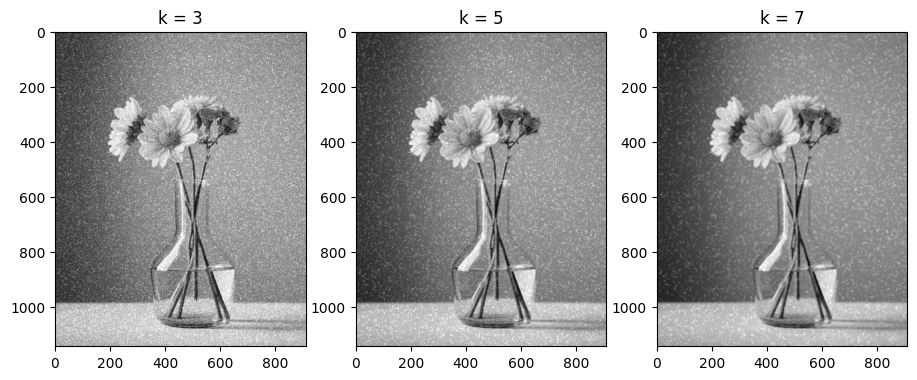

In [15]:
# Шум Гауса
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.medianBlur(image_noise_gauss, k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()


k = 3: MSE = 4.859519729174335 ; SSIM = 0.991458119287637
k = 5: MSE = 14.308875061342167 ; SSIM = 0.9772969137904445
k = 7: MSE = 26.12171340172985 ; SSIM = 0.9622552766701771


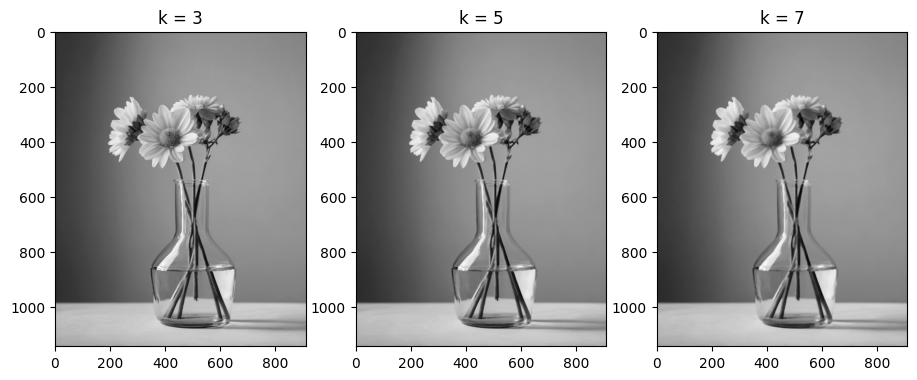

In [16]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.medianBlur(image_noise_sp, k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

Фильтр Гауса

k = 7: MSE = 1224.9054228392222 ; SSIM = 0.5675610712875127
k = 9: MSE = 1208.1238124539934 ; SSIM = 0.6531976718859406
k = 11: MSE = 1200.7678879508649 ; SSIM = 0.7193260120865753


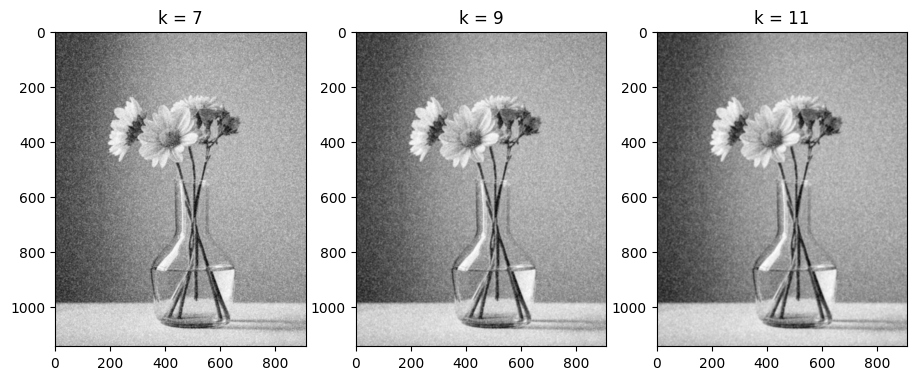

In [17]:
# Шум Гауса
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [7, 9, 11]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.GaussianBlur(image_noise_gauss, (k, k), 0)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

k = 3: MSE = 55.79174334437492 ; SSIM = 0.7073416597770734
k = 5: MSE = 38.1657484511103 ; SSIM = 0.7943071421810642
k = 7: MSE = 34.59648739418476 ; SSIM = 0.8627812577997737


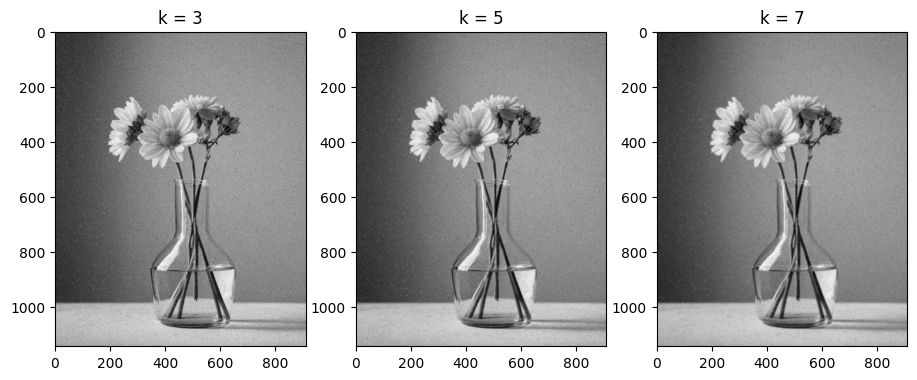

In [18]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.GaussianBlur(image_noise_sp, (k, k), 0)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

Билатериальный фильтр

k = 7: MSE = 1125.974495077291 ; SSIM = 0.43098564886109203
k = 9: MSE = 1097.2034575895595 ; SSIM = 0.47730962269173705
k = 11: MSE = 1087.3780163093486 ; SSIM = 0.5006025459842873


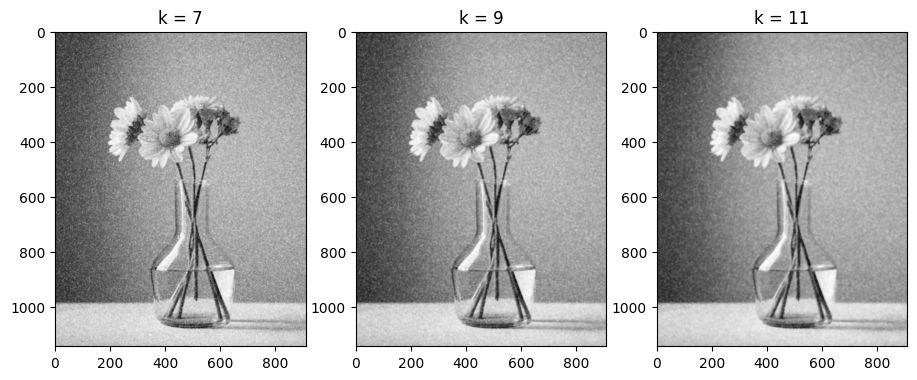

In [19]:
# Шум Гауса
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [7, 9, 11]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.bilateralFilter(image_noise_gauss, k, 105, 105)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

k = 3: MSE = 89.94396680622009 ; SSIM = 0.6666941589318327
k = 5: MSE = 37.00785658968225 ; SSIM = 0.8143476070952422
k = 7: MSE = 30.055635428168323 ; SSIM = 0.8921921408815183


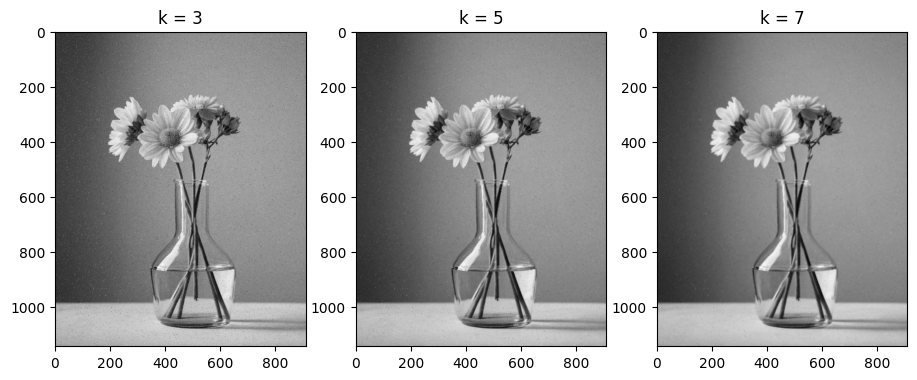

In [20]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [3, 5, 7]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.bilateralFilter(image_noise_sp, k, 105, 105)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

Фильтр нелокальных средних

k = 10: MSE = 3081.563542816832 ; SSIM = 0.07886808315209701
k = 20: MSE = 2862.101861543062 ; SSIM = 0.14998933181670218
k = 30: MSE = 1481.4076992086862 ; SSIM = 0.4475832546978551


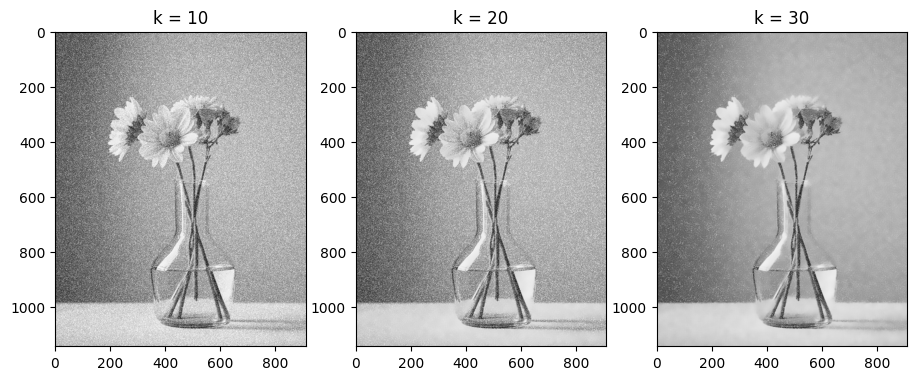

In [21]:
# Шум Гауса
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [10, 20, 30]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.fastNlMeansDenoising(image_noise_gauss, h = k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

k = 10: MSE = 267.7750784029567 ; SSIM = 0.6200439204134739
k = 20: MSE = 29.249437377315665 ; SSIM = 0.9214435180226929
k = 30: MSE = 27.235408232118758 ; SSIM = 0.9446158517577918


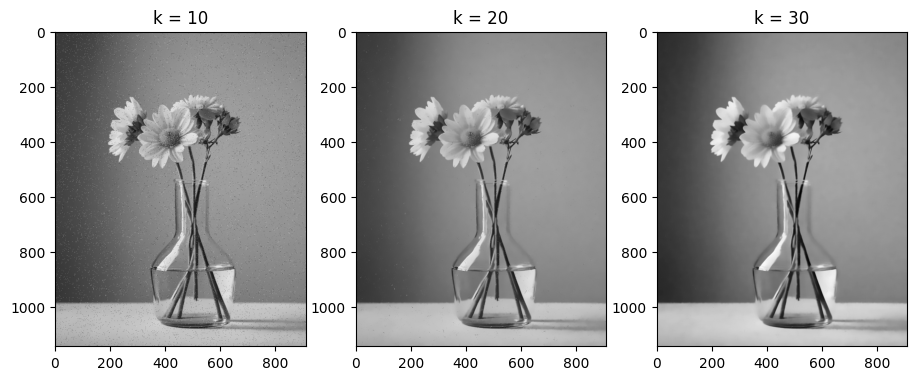

In [22]:
# Шум соль-перец
i = 0

_, plots = plt.subplots(1, 3, figsize=(11, 5))

for k in [10, 20, 30]:
    plots[i].set_title('k = {}'.format(k))
    res = cv2.fastNlMeansDenoising(image_noise_sp, h = k)
    mse_ssim(image_gray, res, 'k = {}'.format(k))
    plots[i].imshow(res, cmap = 'gray')   
    i+=1

plt.show()

# Выяснить, какой фильтр показал лучший результат фильтрации шума.

Лучший результат для шума Гауса показал фильтр Гауса

In [23]:
k = 11
res = cv2.GaussianBlur(image_noise_gauss, (k, k), 0)
mse_ssim(image_gray, res, 'k = {}'.format(k))

k = 11: MSE = 1200.7678879508649 ; SSIM = 0.7193260120865753


Лучший результат для шума соль-перец показал медианный фильтр

In [25]:
k = 3
res = cv2.medianBlur(image_noise_sp, k)
mse_ssim(image_gray, res, 'k = {}'.format(k))

k = 3: MSE = 4.859519729174335 ; SSIM = 0.991458119287637
